In [1]:
import torch
import matplotlib.pyplot as plt
from torch.nn.functional import cosine_similarity
import os

In [3]:
# To verify: are the outputs of full_inference.py and the original code from the
# NeuroFlow repository the same?
# Artifacts in ~/artifacts/ are the same data split used in ./sample_data/ so we
# can use the two directories for comparison.

In [2]:
def assess_similarity(original_embedding, test_embedding):
    assert original_embedding.shape == test_embedding.shape, "Embeddings do not have the same shape"
    assert original_embedding.dtype == test_embedding.dtype, "Embeddings do not have the same data type"

    print("Calculating cosine similarity...")
    similarity = cosine_similarity(original_embedding, test_embedding, dim=-1)
    print("Mean:", similarity.mean().item())
    print("Std:", similarity.std().item())
    print("Min:", similarity.min().item())
    print("Max:", similarity.max().item())
    print("Plotting histogram...")
    plt.hist(similarity.flatten().cpu().numpy(), bins=10)
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    plt.title('Histogram of Cosine Similarities')
    plt.show()

# CLIP Encoding

Calculating cosine similarity...
Mean: 1.0
Std: 0.004192352294921875
Min: 0.70703125
Max: 1.0009765625
Plotting histogram...


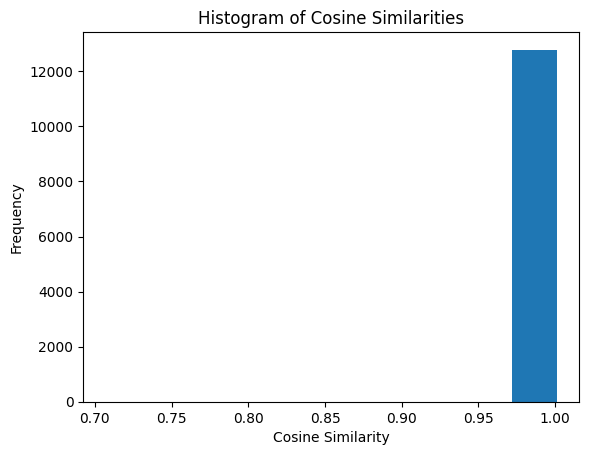

In [3]:
# CLIP encoding
original_clip_encoding = torch.load("../sample_data/sdxl_clip_embeddings.pt")
test_clip_encoding = torch.load("/u/fdammeier/artifacts/img_embeddings.pt")

assess_similarity(original_clip_encoding, test_clip_encoding)

# NeuroVAE Encodings

Calculating cosine similarity...
Mean: 1.0
Std: 1.9803977124865924e-07
Min: 0.9999992847442627
Max: 1.0000004768371582
Plotting histogram...


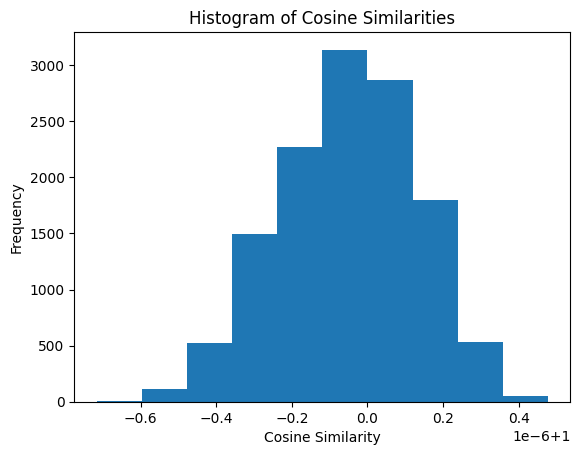

In [25]:
original_neurovae_encoding = torch.load("../sample_data/neurovae_embeddings.pt")
test_neurovae_encoding = torch.load("/u/fdammeier/artifacts/neurovae_embeddings.pt")

assess_similarity(original_neurovae_encoding, test_neurovae_encoding)

In [11]:
original_neurovae_encoding[1,0,:20]

tensor([-0.1334, -0.2672, -0.2782,  1.7230, -0.1896,  0.2679, -0.2044,  0.3700,
        -0.1181,  0.5783,  0.3062, -1.3382, -0.2924, -0.1421,  0.2658,  0.5422,
         0.6965,  0.1492, -0.6726, -0.0928])

In [12]:
test_neurovae_encoding[1,0,:20]

tensor([-0.1334, -0.2672, -0.2782,  1.7230, -0.1896,  0.2679, -0.2044,  0.3700,
        -0.1181,  0.5783,  0.3062, -1.3382, -0.2924, -0.1421,  0.2658,  0.5422,
         0.6965,  0.1492, -0.6726, -0.0928])

True
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


# XFM Transformed Latents

Calculating cosine similarity...
Mean: 0.9323428273200989
Std: 0.012339971959590912
Min: 0.8216580748558044
Max: 0.9645079374313354
Plotting histogram...


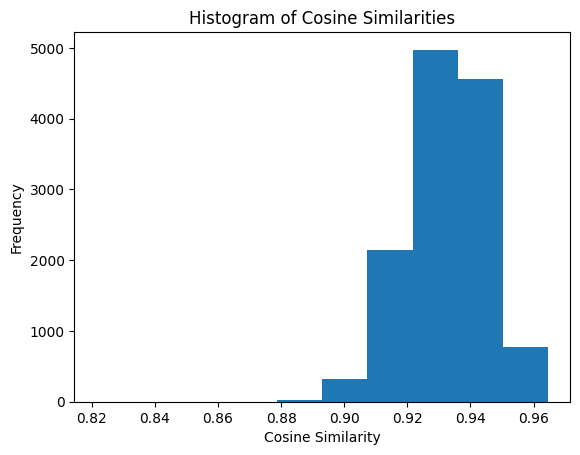

In [5]:
original_img_to_neuro = torch.load("../sample_data/neurovae_embeddings_from_img.pt")
test_img_to_neuro = torch.load("/u/fdammeier/artifacts/neurovae_embeddings_from_img.pt", map_location=torch.device('cpu'))

assess_similarity(original_img_to_neuro, test_img_to_neuro)

Calculating cosine similarity...
Mean: 0.7590411901473999
Std: 0.16507762670516968
Min: -0.13354356586933136
Max: 0.9691542387008667
Plotting histogram...


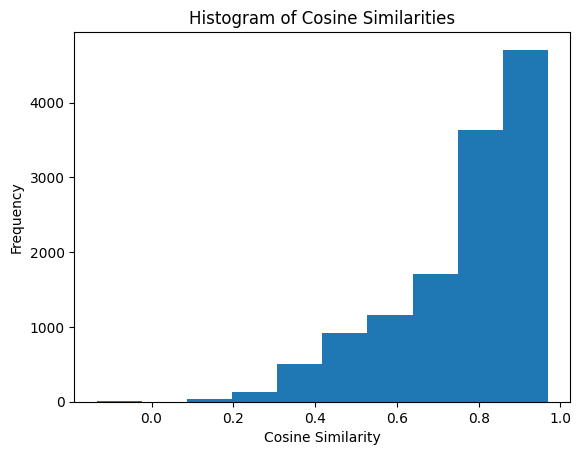

In [8]:
original_neuro_to_img = torch.load("../sample_data/img_embeddings_from_neurovae.pt")
test_neuro_to_img = torch.load("/u/fdammeier/artifacts/img_embeddings_from_neurovae2.pt", map_location=torch.device('cpu'))

assess_similarity(original_neuro_to_img, test_neuro_to_img)

In [ ]:
# Q: could it be that euler sampling really works that much worse in one direction than the other?

# Baseline Similarity (inter-sample, same space)

Cosine similarity is only meaningful relative to how similar *unrelated* samples already are
in a given embedding space. This computes, per token, the cosine similarity between every pair
of *different* samples (excluding self-pairs) to establish a "noise floor" for each space.

In [3]:
def assess_baseline_similarity(embeddings):
    """
    Computes token-wise cosine similarity between all pairs of *different* samples
    in `embeddings` (shape N x T x D), as a baseline for how similar unrelated
    samples already are in this space.
    """
    N = embeddings.shape[0]
    normed = torch.nn.functional.normalize(embeddings, dim=-1)

    # sim[i, j, t] = cosine similarity between sample i and sample j at token t
    sim = torch.einsum("itd,jtd->ijt", normed, normed)

    # drop self-pairs (i == j)
    off_diag_mask = ~torch.eye(N, dtype=torch.bool)
    baseline = sim[off_diag_mask]

    print("Calculating baseline (inter-sample) cosine similarity...")
    print("Mean:", baseline.mean().item())
    print("Std:", baseline.std().item())
    print("Min:", baseline.min().item())
    print("Max:", baseline.max().item())
    print("Plotting histogram...")
    plt.hist(baseline.flatten().cpu().numpy(), bins=10)
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    plt.title('Histogram of Baseline (Inter-Sample) Cosine Similarities')
    plt.show()

    return baseline

## CLIP Token Baseline

Calculating baseline (inter-sample) cosine similarity...
Mean: 0.2332763671875
Std: 0.10882568359375
Min: -0.34912109375
Max: 0.85546875
Plotting histogram...


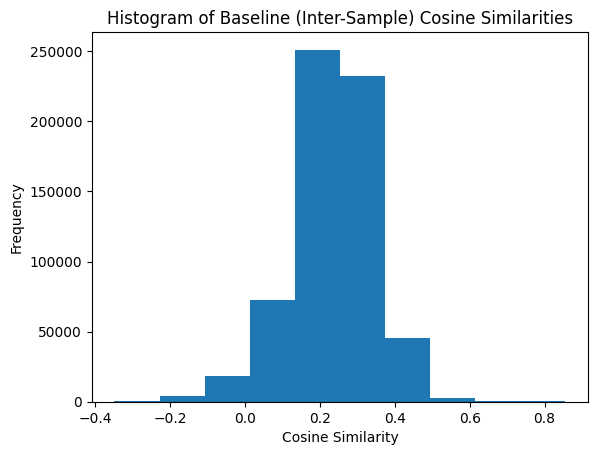

In [8]:
clip_baseline = assess_baseline_similarity(original_clip_encoding)

## NeuroVAE Latent Baseline

Calculating baseline (inter-sample) cosine similarity...
Mean: 0.01192229613661766
Std: 0.1839306503534317
Min: -0.5465961694717407
Max: 0.8828387260437012
Plotting histogram...


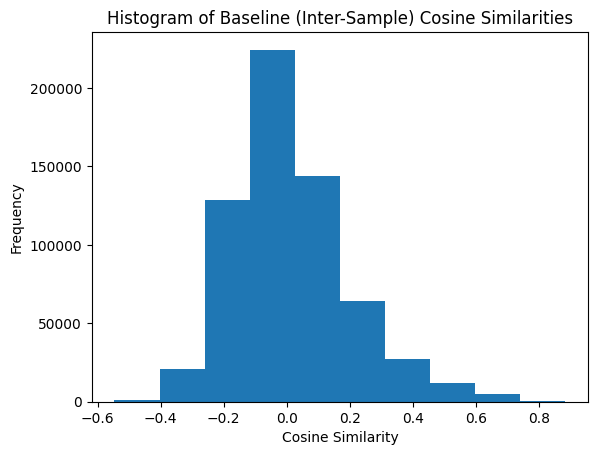

In [9]:
neurovae_baseline = assess_baseline_similarity(original_neurovae_encoding)

In [16]:
test_neuro_to_img1 = torch.load("/u/fdammeier/artifacts/img_embeddings_from_neurovae1.pt", map_location=torch.device('cpu'))
test_neuro_to_img = torch.load("/u/fdammeier/artifacts/img_embeddings_from_neurovae.pt", map_location=torch.device('cpu'))

In [19]:
test_neuro_to_img1[1,0,:10]

tensor([-0.0095,  0.3784, -0.0274,  0.8651, -0.8693,  0.4662, -0.4693,  0.1957,
        -0.0499,  0.7911])

In [20]:
test_neuro_to_img[1,0,:10]

tensor([-0.0095,  0.3784, -0.0274,  0.8651, -0.8693,  0.4662, -0.4693,  0.1957,
        -0.0499,  0.7911])

Calculating cosine similarity...
Mean: 0.999998927116394
Std: 2.928681715275161e-05
Min: 0.9972738027572632
Max: 1.0000004768371582
Plotting histogram...


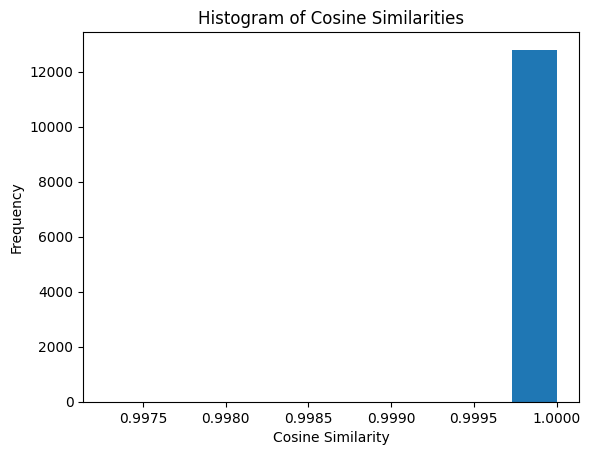

In [23]:
assess_similarity(test_neuro_to_img1, test_neuro_to_img)